<a href="https://colab.research.google.com/github/Dinhho1902/AI-For-Beginners/blob/main/Assigment_2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression**

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# Load dataset
file_location = "/content/Loan_default.csv"
Data = pd.read_csv(file_location)
Data = Data.drop(columns='LoanID')

# Select numerical columns (int and float types) for further analysis and model training.
num = Data.select_dtypes(include=['int', 'float'])

def ColumnTrans(cat):# Iterate over each column in the DataFrame.
  for column in cat.columns:
# Get unique values for the column
    unique_values = cat[column].unique()
# Create a mapping of each unique value to a corresponding integer
    value_map = {value: index for index, value in enumerate(unique_values)}
# Map the column's categorical values to their integer indices
    cat[column] = cat[column].map(value_map)
  return cat

cat = Data.select_dtypes(include='object')
cat = ColumnTrans(cat)
df = pd.concat([num, cat], axis=1)

In [20]:
# Create new financial ratio features
df['DebtToIncome'] = df['LoanAmount'] / df['Income']
df['DebtToIncome'] = df['DebtToIncome'].replace([np.inf, -np.inf], np.nan)
df['DebtToIncome'] = df['DebtToIncome'].fillna(df['DebtToIncome'].mean())
df['LoanToCredit'] = df['LoanAmount'] / df['CreditScore']
df['LoanToCredit'] = df['LoanToCredit'].replace([np.inf, -np.inf], np.nan)
df['LoanToCredit'] = df['LoanToCredit'].fillna(df['LoanToCredit'].mean())
df['CreditUtilization'] = df['LoanAmount'] / (df['NumCreditLines'] * 10000)
df['CreditUtilization'] = df['CreditUtilization'].replace([np.inf, -np.inf], np.nan)
df['CreditUtilization'] = df['CreditUtilization'].fillna(df['CreditUtilization'].mean())

In [21]:
# Separate features (X) from the target variable (y)
x1 = df.drop(columns='Default') # Features: All columns except 'Default'
y1 = df['Default'] # Target: 'Default' column

In [22]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42, stratify=y1)

In [23]:
# Apply Random Under-Sampling to decrease the majority class
rus = RandomUnderSampler(sampling_strategy=0.8, random_state=42)
x_train_res, y_train_res = rus.fit_resample(x_train, y_train)
# Scale the features
scaler = StandardScaler()
x_train_res_scaled = scaler.fit_transform(x_train_res)
x_test_scaled = scaler.transform(x_test)

In [24]:
# Calculate mutual information
mutual_info_scores = mutual_info_classif(x_train_res_scaled, y_train_res, random_state=42)
mutual_info_series = pd.Series(mutual_info_scores, index=x_train_res.columns)
sorted_mutual_info = mutual_info_series.sort_values(ascending=False)
print("Mutual Information Scores:")
print(sorted_mutual_info)

Mutual Information Scores:
Age                  0.032270
DebtToIncome         0.028312
InterestRate         0.023837
Income               0.015766
LoanToCredit         0.011318
MonthsEmployed       0.010023
LoanAmount           0.008363
EmploymentType       0.004796
HasMortgage          0.004037
HasDependents        0.004024
CreditUtilization    0.002583
CreditScore          0.002569
HasCoSigner          0.002358
MaritalStatus        0.002063
LoanPurpose          0.001950
Education            0.001261
DTIRatio             0.000672
NumCreditLines       0.000627
LoanTerm             0.000281
dtype: float64


In [25]:
# Train a LogisticRegression to get feature importances
model_lr = LogisticRegression(random_state=42)
model_lr.fit(x_train_res_scaled, y_train_res)

LogisticRegression(random_state=42)

In [26]:
# Get and sort feature importances from LogisticRegression
# For LogisticRegression, coefficients can be used as a measure of feature importance
feature_importances = pd.Series(abs(model_lr.coef_[0]), index=x_train_res.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)
print("\nFeature Importances from LogisticRegression (Absolute Coefficients):")
print(sorted_feature_importances)


Feature Importances from LogisticRegression (Absolute Coefficients):
Age                  0.587325
DebtToIncome         0.564269
InterestRate         0.461735
MonthsEmployed       0.332074
HasCoSigner          0.136488
HasDependents        0.133720
CreditScore          0.119371
NumCreditLines       0.117293
HasMortgage          0.083349
DTIRatio             0.069242
EmploymentType       0.054862
Education            0.029587
Income               0.020768
MaritalStatus        0.018697
LoanPurpose          0.017819
CreditUtilization    0.017504
LoanAmount           0.006993
LoanTerm             0.005608
LoanToCredit         0.002977
dtype: float64


In [27]:
# Select top features based on mutual information and feature importance
top_n = 10
top_mutual_info_features = sorted_mutual_info.head(top_n).index.tolist()
top_feature_importance_features = sorted_feature_importances.head(top_n).index.tolist()
# Combine the feature lists and remove duplicates
selected_features = list(set(top_mutual_info_features + top_feature_importance_features))
print("Selected Features:")
print(selected_features)

Selected Features:
['Age', 'LoanAmount', 'CreditScore', 'InterestRate', 'MonthsEmployed', 'Income', 'LoanToCredit', 'EmploymentType', 'DTIRatio', 'HasCoSigner', 'DebtToIncome', 'NumCreditLines', 'HasDependents', 'HasMortgage']


In [28]:
# Create new training and testing DataFrames with selected features
x_train_selected = x_train_res[selected_features]
x_test_selected = x_test[selected_features]# Display the shapes of the new DataFrames to verify the selection
print("\nShape of Selected Training Features (x_train_selected):", x_train_selected.shape)
print("Shape of Selected Testing Features (x_test_selected):", x_test_selected.shape)


Shape of Selected Training Features (x_train_selected): (53374, 14)
Shape of Selected Testing Features (x_test_selected): (51070, 14)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Initialize the Logistic Regression model
model_selected = LogisticRegression(random_state=42)
# Train the model using the selected training data
model_selected.fit(x_train_selected, y_train_res)
# Use the trained model to make predictions on the selected test data
prediction_selected = model_selected.predict(x_test_selected)
# Calculate accuracy, precision, recall, and F1 score
accuracy_selected = accuracy_score(y_test, prediction_selected)
precision_selected = precision_score(y_test, prediction_selected)
recall_selected = recall_score(y_test, prediction_selected)
f1_selected = f1_score(y_test, prediction_selected)
# Display the metrics
print(f"Accuracy with selected features: {accuracy_selected:.4f}")
print(f"Precision with selected features: {precision_selected:.4f}")
print(f"Recall with selected features: {recall_selected:.4f}")
print(f"F1 Score with selected features: {f1_selected:.4f}")

Accuracy with selected features: 0.7335
Precision with selected features: 0.2293
Recall with selected features: 0.5485
F1 Score with selected features: 0.3234


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


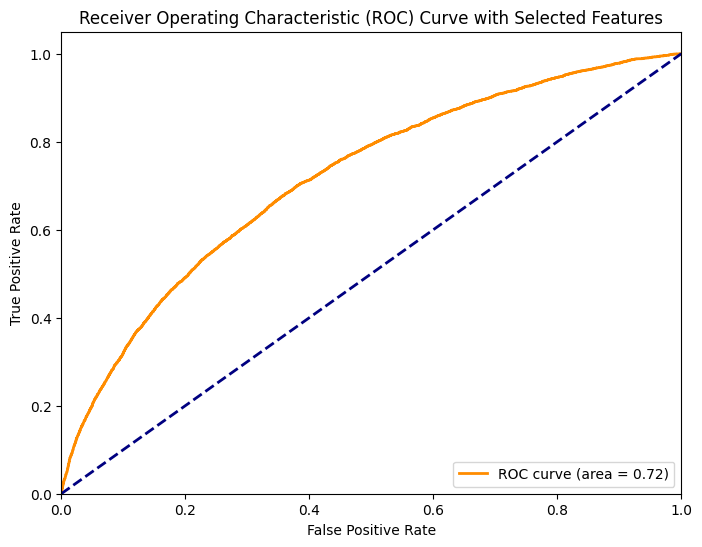

In [35]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
# Get predicted probabilities for the positive class (class 1) from the model with selected features
prediction_proba_selected = model_selected.predict_proba(x_test_selected)[:, 1]# Calculate ROC curve and AUC
fpr_selected, tpr_selected, thresholds_selected = roc_curve(y_test, prediction_proba_selected)
roc_auc_selected = auc(fpr_selected, tpr_selected)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_selected, tpr_selected, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' %
roc_auc_selected)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with Selected Features')
plt.legend(loc="lower right")
plt.show()

In [36]:
# Print AUC score
print(f"AUC Score with selected features: {roc_auc_selected:.4f}")

AUC Score with selected features: 0.7167


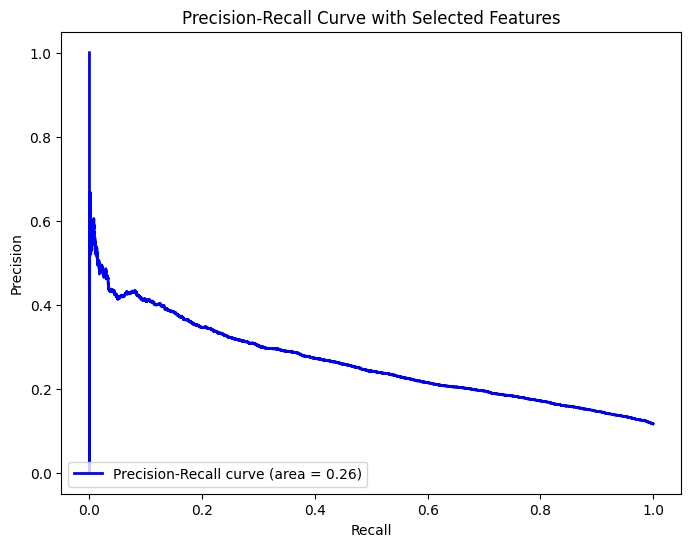

In [39]:
# Calculate Precision-Recall curve and AUC
precision_selected, recall_selected, _ = precision_recall_curve(y_test, prediction_proba_selected)
pr_auc_selected = auc(recall_selected, precision_selected)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_selected, precision_selected, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' %
pr_auc_selected)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Selected Features')
plt.legend(loc="lower left")
plt.show()

In [40]:
# Print AUC score for Precision-Recall curve
print(f"Precision-Recall AUC Score with selected features: {pr_auc_selected:.4f}")

Precision-Recall AUC Score with selected features: 0.2610


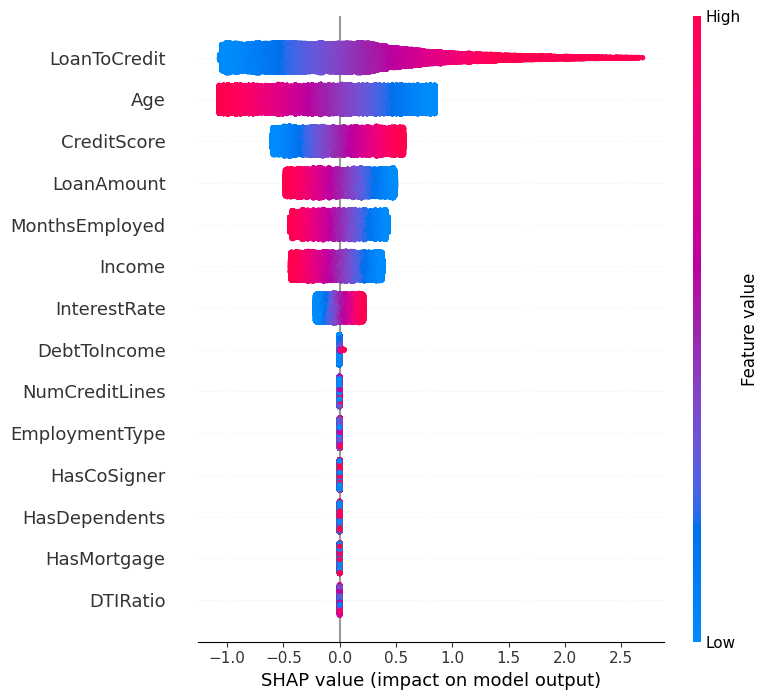

In [43]:
import shap
# Use a subset of the selected training data for SHAP value calculation for performance
X_train_subset_selected = x_train_selected.sample(n=200, random_state=42)

# Create a masker with max_samples set to the size of the background dataset
masker = shap.maskers.Independent(X_train_subset_selected, max_samples=len(X_train_subset_selected))

# Create a SHAP explainer object, passing the explicit masker
explainer_selected = shap.LinearExplainer(model_selected, masker)

# Calculate SHAP values for the selected test set
shap_values_selected = explainer_selected.shap_values(x_test_selected)
# Summarize the SHAP values to get an overview of feature importance
shap.summary_plot(shap_values_selected, x_test_selected)
# Plot SHAP values for a single instance (e.g., the first instance in the selected test set)
shap.initjs()
shap.force_plot(explainer_selected.expected_value, shap_values_selected[0,:], x_test_selected.iloc[0,:])